# Dog vs Cat Classification with ANN

This notebook builds an end-to-end binary image classification pipeline using TensorFlow Keras and scikit-learn.

The notebook is GPU-aware and will use a GPU automatically when the runtime exposes one.

In [1]:
# Core Python and numerical libraries
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow Keras utilities for image loading and ANN modeling
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# scikit-learn utilities and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, cohen_kappa_score, zero_one_loss,
    roc_auc_score, precision_recall_curve, roc_curve, auc,
    log_loss, brier_score_loss, hinge_loss
)

# Reproducibility: set random seeds for Python, NumPy, and TensorFlow
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Detect GPU availability and enable the fastest safe runtime settings.
# If a GPU is present, TensorFlow will use it automatically for model training.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled for GPU acceleration.')
    except Exception as exc:
        print('Mixed precision not enabled:', exc)

    USE_GPU = True
    print('GPU devices detected:', gpus)
else:
    USE_GPU = False
    print('No GPU detected. Training will run on CPU in this environment.')
    print('On native Windows, TensorFlow 2.11+ typically does not use CUDA GPU support.')

# Plot style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('TensorFlow version:', tf.__version__)

No GPU detected. Training will run on CPU in this environment.
On native Windows, TensorFlow 2.11+ typically does not use CUDA GPU support.
TensorFlow version: 2.21.0


## Step 1: Data Loading and Preprocessing

This section loads the Kaggle Animal Faces images, resizes them, normalizes pixels, flattens the tensors for the ANN, and splits the dataset into train, validation, and test sets.

Using dataset folder: C:\Coding\Applied Machine Learning\Dog_vs_Cat_ANN\afhq
Train folder: C:\Coding\Applied Machine Learning\Dog_vs_Cat_ANN\afhq\train
Validation/Test folder: C:\Coding\Applied Machine Learning\Dog_vs_Cat_ANN\afhq\val
Target image size: (64, 64)
Found 9892 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Train batches: 310
Validation batches: 16
Test batches: 16


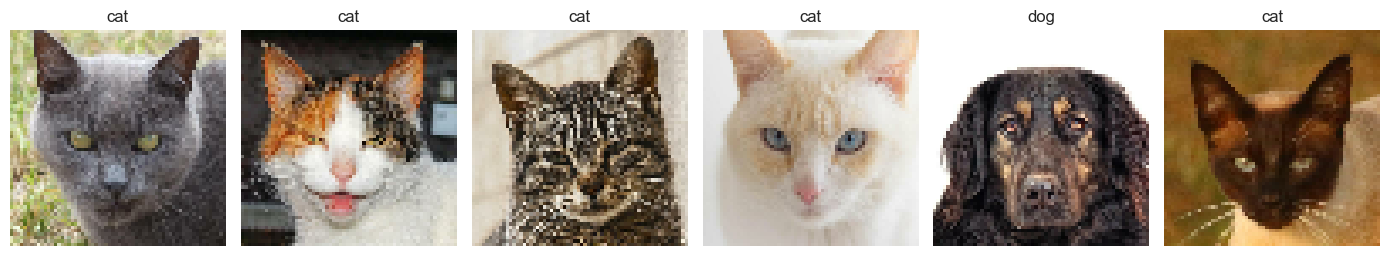

In [2]:
from pathlib import Path
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ===========================
# Dataset configuration
# ===========================

# IMPORTANT:
# Update this path to your local extracted Kaggle dataset folder.
# Default below points to the downloaded Kaggle Animal Faces data in this project.
DATASET_DIR = Path('C:/Coding/Applied Machine Learning/Dog_vs_Cat_ANN/afhq')
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'val'

# Image size for ANN input (smaller size keeps memory manageable for Flatten-based ANN)
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Binary classes to keep for this task
CLASS_NAMES = ['cat', 'dog']

# Optional cap per class for faster experiments; use None to load all
MAX_IMAGES_PER_CLASS = None

# Sanity check that dataset folders exist
if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    raise FileNotFoundError(
        f'Dataset folders not found: {TRAIN_DIR} or {VAL_DIR}. Please verify the extracted Kaggle dataset path.'
    )

print('Using dataset folder:', DATASET_DIR.resolve())
print('Train folder:', TRAIN_DIR.resolve())
print('Validation/Test folder:', VAL_DIR.resolve())
print('Target image size:', IMG_SIZE)

# Build streamed TensorFlow datasets so images are loaded on demand and prefetched for the GPU.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=True,
    seed=SEED,
)

# Split the provided val folder into validation and test subsets.
val_raw_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=True,
    seed=SEED,
)

total_val_count = tf.data.experimental.cardinality(val_raw_ds).numpy()
if total_val_count < 2:
    raise ValueError('The validation folder must contain at least 2 images to split into validation and test sets.')

val_count = total_val_count // 2
test_count = total_val_count - val_count

val_ds = val_raw_ds.take(val_count)
test_ds = val_raw_ds.skip(val_count)

# Optional per-class limiting for faster experiments.
# This is applied after loading because the dataset is streamed from disk.
if MAX_IMAGES_PER_CLASS is not None:
    def limit_dataset(dataset, class_limit):
        class_slices = []
        for class_index in range(len(CLASS_NAMES)):
            filtered = dataset.filter(lambda image, label, class_index=class_index: tf.equal(label, class_index))
            class_slices.append(filtered.take(class_limit))
        combined = class_slices[0]
        for ds_part in class_slices[1:]:
            combined = combined.concatenate(ds_part)
        return combined.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)

    train_ds = limit_dataset(train_ds, MAX_IMAGES_PER_CLASS)
    val_ds = limit_dataset(val_ds, max(1, MAX_IMAGES_PER_CLASS // 2))
    test_ds = limit_dataset(test_ds, max(1, MAX_IMAGES_PER_CLASS // 2))

# Cache, batch, and prefetch the input pipeline for GPU throughput.
# The ANN still uses dense layers, but the input pipeline itself is now GPU-friendly.
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64 if USE_GPU else 32

train_ds = train_ds.cache().shuffle(2048, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Train batches:', tf.data.experimental.cardinality(train_ds).numpy())
print('Validation batches:', tf.data.experimental.cardinality(val_ds).numpy())
print('Test batches:', tf.data.experimental.cardinality(test_ds).numpy())

# Quick visual check of sample images from the streamed dataset
plt.figure(figsize=(14, 3))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(1, 6, i + 1)
        plt.imshow(batch_images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[int(batch_labels[i].numpy())])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Build an ANN (no convolutional layers)
# This cell expects the dataset pipeline from the previous cell to have been run.
required_names = [
    'train_ds',
    'val_ds',
    'test_ds',
    'IMG_HEIGHT',
    'IMG_WIDTH',
    'USE_GPU',
    'CLASS_NAMES',
    'np',
    'pd',
    'tf',
    'plt',
    'sns',
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        'Run the data-loading cell before the model cell. Missing: ' + ', '.join(missing_names)
    )

model = Sequential([
    # Rescale inside the model so the pipeline stays fully TensorFlow-native.
    tf.keras.layers.Rescaling(1.0 / 255.0, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Flatten image to 1D feature vector
    Flatten(),

    # Fully connected hidden block 1
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.40),

    # Fully connected hidden block 2
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.30),

    # Fully connected hidden block 3
    Dense(64, activation='relu'),
    Dropout(0.20),

    # Binary output neuron with sigmoid probability
    # Keep the output in float32 for numerical stability when mixed precision is active.
    Dense(1, activation='sigmoid', dtype='float32')
])

# Compile model with Adam optimizer and helpful monitoring metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Callback 1: stop training early if validation loss does not improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

# Callback 2: reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Use a larger batch size when GPU is available to improve throughput.
# Keep CPU batch size smaller to reduce memory pressure.
EPOCHS = 40
BATCH_SIZE = 64 if USE_GPU else 32

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate final model on test split
test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(test_ds, verbose=0)
print('\nTest loss:', round(test_loss, 4))
print('Test accuracy:', round(test_acc, 4))
print('Test ROC-AUC (Keras metric):', round(test_auc, 4))
print('Test precision:', round(test_prec, 4))
print('Test recall:', round(test_rec, 4))

# Collect predictions from the streamed test dataset
y_true = []
y_proba = []
for batch_images, batch_labels in test_ds:
    batch_predictions = model.predict(batch_images, verbose=0).ravel()
    y_true.extend(batch_labels.numpy().tolist())
    y_proba.extend(batch_predictions.tolist())

y_test = np.array(y_true)
y_proba = np.array(y_proba)

# Convert probabilities to hard labels using threshold 0.5
THRESHOLD = 0.5
y_pred = (y_proba >= THRESHOLD).astype(int)

# Compute confusion matrix and extract TN, FP, FN, TP
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Custom specificity (true negative rate) calculation
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Choose beta for F-Beta score (beta > 1 emphasizes recall)
BETA = 2.0

# Threshold-dependent metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
f_beta = fbeta_score(y_test, y_pred, beta=BETA, zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
zol = zero_one_loss(y_test, y_pred)

# Probability-dependent metrics
roc_auc = roc_auc_score(y_test, y_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_curve, prec_curve)
ll = log_loss(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

# Hinge loss concept for ANN probabilities:
# 1) Convert true labels from {0,1} to {-1,+1}
# 2) Convert probability to signed score in [-1, +1] via score = 2p - 1
y_signed = np.where(y_test == 1, 1, -1)
decision_scores = 2.0 * y_proba - 1.0
hinge = hinge_loss(y_signed, decision_scores)

# Store all metrics in a table for clear output
metrics_table = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity (TNR)',
        'F1-Score', f'F-Beta Score (beta={BETA})', 'MCC', 'Cohen Kappa', 'Zero-One Loss',
        'ROC-AUC', 'PR-AUC', 'Log Loss', 'Brier Score', 'Hinge Loss'
    ],
    'Value': [
        accuracy, precision, recall, specificity,
        f1, f_beta, mcc, kappa, zol,
        roc_auc, pr_auc, ll, brier, hinge
    ]
})

print('Confusion Matrix values:')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}\n')

display(metrics_table.style.format({'Value': '{:.6f}'}))

# ------------------------------
# 1) Training and validation curves
# ------------------------------
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history_df['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_df['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss curve
axes[1].plot(history_df['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_df['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------
# 2) Confusion matrix heatmap
# ------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred Cat (0)', 'Pred Dog (1)'],
    yticklabels=['True Cat (0)', 'True Dog (1)']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ------------------------------
# 3) ROC curve
# ------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ------------------------------
# 4) Precision-Recall curve
# ------------------------------
plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, linewidth=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Epoch 1/40


c:\Users\Prana\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


310/310 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.7579 - auc: 0.8391 - loss: 0.5168 - precision: 0.7475 - recall: 0.7470 - val_accuracy: 0.8400 - val_auc: 0.9214 - val_loss: 0.3575 - val_precision: 0.8403 - val_recall: 0.8533 - learning_rate: 0.0010
Epoch 2/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.8216 - auc: 0.8974 - loss: 0.4095 - precision: 0.8120 - recall: 0.8166 - val_accuracy: 0.8760 - val_auc: 0.9512 - val_loss: 0.2950 - val_precision: 0.9156 - val_recall: 0.8378 - learning_rate: 0.0010
Epoch 3/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8473 - auc: 0.9214 - loss: 0.3582 - precision: 0.8408 - recall: 0.8403 - val_accuracy: 0.8240 - val_auc: 0.9449 - val_loss: 0.3903 - val_precision: 0.9524 - val_recall: 0.6950 - learning_rate: 0.0010
Epoch 4/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.8539 - auc: 0.9289 - loss: 0.3404 - precision: 0.8475 - recall: 0.8476 - val_accuracy: 0.8240 - val_auc: 0.9374 - val_loss: 0.3954 - val_pr